# Compare ADMET vs non-ADMET runs

This notebook plots optimization traces (loss and predicted affinity) for two runs and compares report-level metrics (baseline vs ADMET vs no-ADMET).

Update the signatures below if you rerun the pipeline.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

base = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeline_output_assay")

# Signatures to compare


# ### sars cov--- RDKit path fingerprint + Tversky 
# a = {
#     "label": "1024",
#     "opt": "ab8322096ede",
#     "report": "c302de47eac5",
# }

#### sars-cov ... tanimoto sim full morgan finger print 1024 , 3 
# a = {
#     "label": "1024",
#     "opt": "ab8322096ede",
#     "report": "c3ee018a637a",
# }

#### sars-cov ...  my piplien 
# b = {
#     "label": "2048",
#     "opt": "ab8322096ede",
#     "report": "b7ad180a2493",
# }

#### sars-cov ...  random
# c = {
#     "label": "4096",
#     "opt": "5e2e1ff84378",
#     "report": "df12841610db",
# }

#### admet average

#### jep the followig one 
c = {
    "label": "1024",
    "opt": "69e264ec4e6b",
    "report": "1960df5b3abe",
}

runs = [c]
# for r in runs:
#     if r in [b, c]:
#         continue
#     r["opt_path"] = base / "optimization" / r["opt"] / "optimization_trace_topk_stats.csv"
#     r["report_path"] = base / "report" / r["report"] / "nevermore_report.csv"
#     if not r["opt_path"].exists():
#         raise FileNotFoundError(r["opt_path"])
#     if not r["report_path"].exists():
#         raise FileNotFoundError(r["report_path"])
    
base = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeline_output")

for r in runs:
    # if r==a:
    #     continue
    r["opt_path"] = base / "optimization" / r["opt"] / "optimization_trace_topk_stats.csv"
    r["report_path"] = base / "report" / r["report"] / "nevermore_report.csv"
    if not r["opt_path"].exists():
        raise FileNotFoundError(r["opt_path"])
    if not r["report_path"].exists():
        raise FileNotFoundError(r["report_path"])


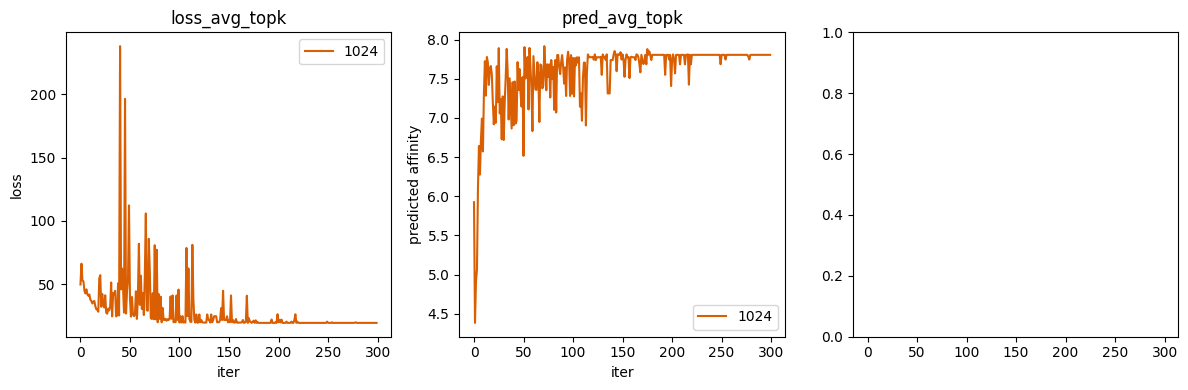

In [32]:
# Load traces for all runs
traces = {}
for r in runs:
    traces[r["label"]] = pd.read_csv(r["opt_path"])

# Plot loss_avg_topk and pred_avg_topk
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
colors = {
    "1024": "#d95f02",
    "2048": "#1b9e77",
    "4096": "#7570b3",
}
for label, df in traces.items():
    axes[0].plot(df["iter"], df["loss_avg_topk"], label=label, color=colors.get(label))
    axes[1].plot(df["iter"], df["pred_avg_topk"], label=label, color=colors.get(label))

axes[0].set_title("loss_avg_topk")
axes[0].set_xlabel("iter")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].set_title("pred_avg_topk")
axes[1].set_xlabel("iter")
axes[1].set_ylabel("predicted affinity")
axes[1].legend()

fig.tight_layout()
plt.show()


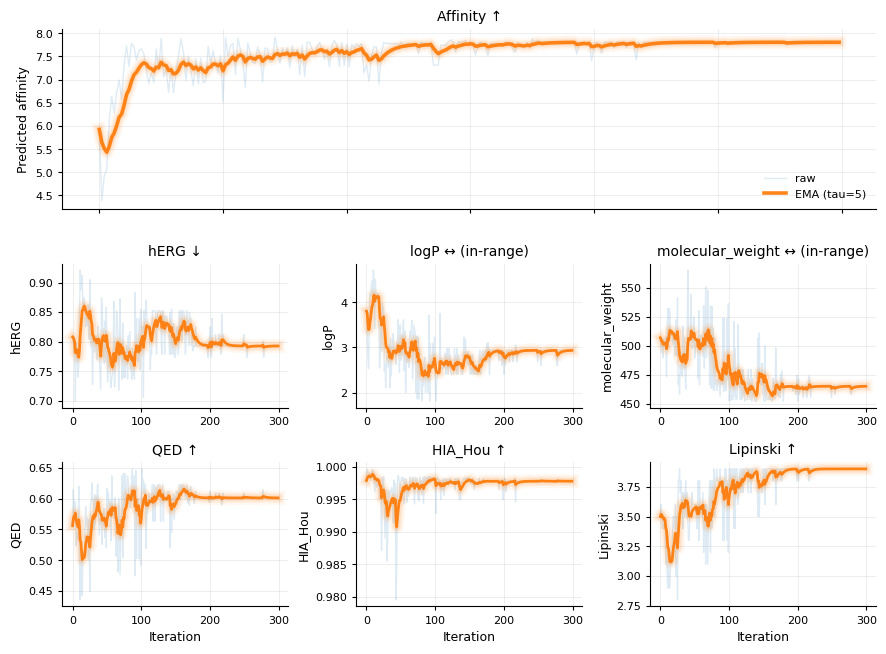

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- paper-ish matplotlib defaults --------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------- inputs --------------------
col = "admet_values_best"   # JSON strings
aff_col = "pred_avg_topk"   # scalar
features = ["hERG", "logP", "molecular_weight", "QED", "HIA_Hou", "Lipinski"]

# choose x axis
t = pd.to_numeric(df["iter"], errors="coerce") if "iter" in df.columns else pd.Series(df.index, index=df.index)
t = pd.Series(t.values, index=df.index).astype(float)

tau = 5.0  # time-weighted EMA smoothing

# -------------------- HOW TO DISPLAY "better" arrows --------------------
# Edit these to match YOUR paper's definition/constraints.
# dir: "up" (higher better), "down" (lower better), "range" (in-range better)
goals = {
    "Affinity": {"dir": "up"},
    "hERG": {"dir": "down"},
    "QED": {"dir": "up"},
    "HIA_Hou": {"dir": "up"},
    "Lipinski": {"dir": "up"},
    "logP": {"dir": "range"},               # or {"dir":"down"} if you want lower
    "molecular_weight": {"dir": "down"},   # or {"dir":"down"} if you want lower
    # Optional: if you want to show numeric target ranges in the title:
    # "logP": {"dir":"range", "range": (None, 5.0)},   # ≤ 5.0
    # "molecular_weight": {"dir":"range", "range": (200.0, 500.0)},  # 200–500
}

ARROW = {"up": "↑", "down": "↓", "range": "↔"}

def format_title(name: str) -> str:
    g = goals.get(name, {})
    d = g.get("dir", None)
    sym = ARROW.get(d, "")
    title = f"{name} {sym}".rstrip()

    if d == "range":
        lo, hi = g.get("range", (None, None))
        if lo is None and hi is None:
            title += " (in-range)"
        else:
            if lo is None:
                rng = f"≤{hi:g}"
            elif hi is None:
                rng = f"≥{lo:g}"
            else:
                rng = f"{lo:g}–{hi:g}"
            title += f" ({rng})"
    return title

# -------------------- helpers --------------------
def time_weighted_ema(y: pd.Series, t: pd.Series, tau: float) -> pd.Series:
    y = pd.to_numeric(y, errors="coerce")
    t = pd.to_numeric(t, errors="coerce")
    out = pd.Series(index=y.index, dtype="float64")

    first = y.first_valid_index()
    if first is None:
        return out

    out.loc[first] = y.loc[first]
    prev_idx = first

    for idx in y.loc[first:].index[1:]:
        yi = y.loc[idx]
        if pd.isna(yi):
            out.loc[idx] = out.loc[prev_idx]
            prev_idx = idx
            continue

        dt = t.loc[idx] - t.loc[prev_idx]
        if not np.isfinite(dt) or dt < 0:
            dt = 0.0

        alpha = 1.0 - np.exp(-dt / tau) if tau > 0 else 1.0
        out.loc[idx] = out.loc[prev_idx] + alpha * (yi - out.loc[prev_idx])
        prev_idx = idx

    return out

def glow_line(ax, x, y, lw_main=2.2, alpha_main=0.95, label=None):
    main, = ax.plot(x, y, linewidth=lw_main, alpha=alpha_main, label=label)
    c = main.get_color()
    for lw, a in [(10, 0.06), (7, 0.08), (5, 0.10)]:
        ax.plot(x, y, linewidth=lw, alpha=a, color=c)
    return main

def style_axis(ax):
    ax.grid(True, linewidth=0.6, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -------------------- parse ADMET json column --------------------
admet_dicts = df[col].apply(lambda x: json.loads(x) if isinstance(x, str) else (x if isinstance(x, dict) else {}))
admet_df = pd.json_normalize(admet_dicts)
admet_df.index = df.index

# -------------------- figure layout: affinity (top) + 2x3 ADMET --------------------
fig = plt.figure(figsize=(10.5, 7.5))
gs = fig.add_gridspec(nrows=3, ncols=3, height_ratios=[1.25, 1.0, 1.0], hspace=0.35, wspace=0.30)

# --- Top: affinity ---
ax_aff = fig.add_subplot(gs[0, :])
y_aff = pd.to_numeric(df[aff_col], errors="coerce") if aff_col in df.columns else pd.Series(index=df.index, dtype=float)
y_aff_ema = time_weighted_ema(y_aff, t, tau=tau)

ax_aff.plot(t, y_aff, linewidth=1.0, alpha=0.14, label="raw")
glow_line(ax_aff, t, y_aff_ema, lw_main=2.6, alpha_main=0.95, label=f"EMA (tau={tau:g})")

ax_aff.set_title(format_title("Affinity"))
ax_aff.set_ylabel("Predicted affinity")
style_axis(ax_aff)
ax_aff.legend(frameon=False, loc="best")
ax_aff.tick_params(labelbottom=False)

# --- Bottom: 6 ADMET panels ---
axes = [
    fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2]),
    fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]), fig.add_subplot(gs[2, 2]),
]

for ax, f in zip(axes, features):
    style_axis(ax)

    if f not in admet_df.columns:
        ax.text(0.5, 0.5, f"Missing: {f}", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    y = pd.to_numeric(admet_df[f], errors="coerce")
    y_ema = time_weighted_ema(y, t, tau=tau)

    ax.plot(t, y, linewidth=1.0, alpha=0.14)
    glow_line(ax, t, y_ema, lw_main=2.0, alpha_main=0.95)

    ax.set_title(format_title(f), pad=6)
    ax.set_ylabel(f)

# x-label only on bottom row
for ax in axes[-3:]:
    ax.set_xlabel("Iteration")

# Optional: save for paper
# fig.savefig("affinity_admet_panel.pdf", bbox_inches="tight")
# fig.savefig("affinity_admet_panel.png", dpi=300, bbox_inches="tight")

plt.show()


'{"hERG": 0.7791511178016662, "logP": 2.973700000000001, "molecular_weight": 323.396, "QED": 0.4159362560722793, "HIA_Hou": 0.9922124981880188, "Lipinski": 4.0}'

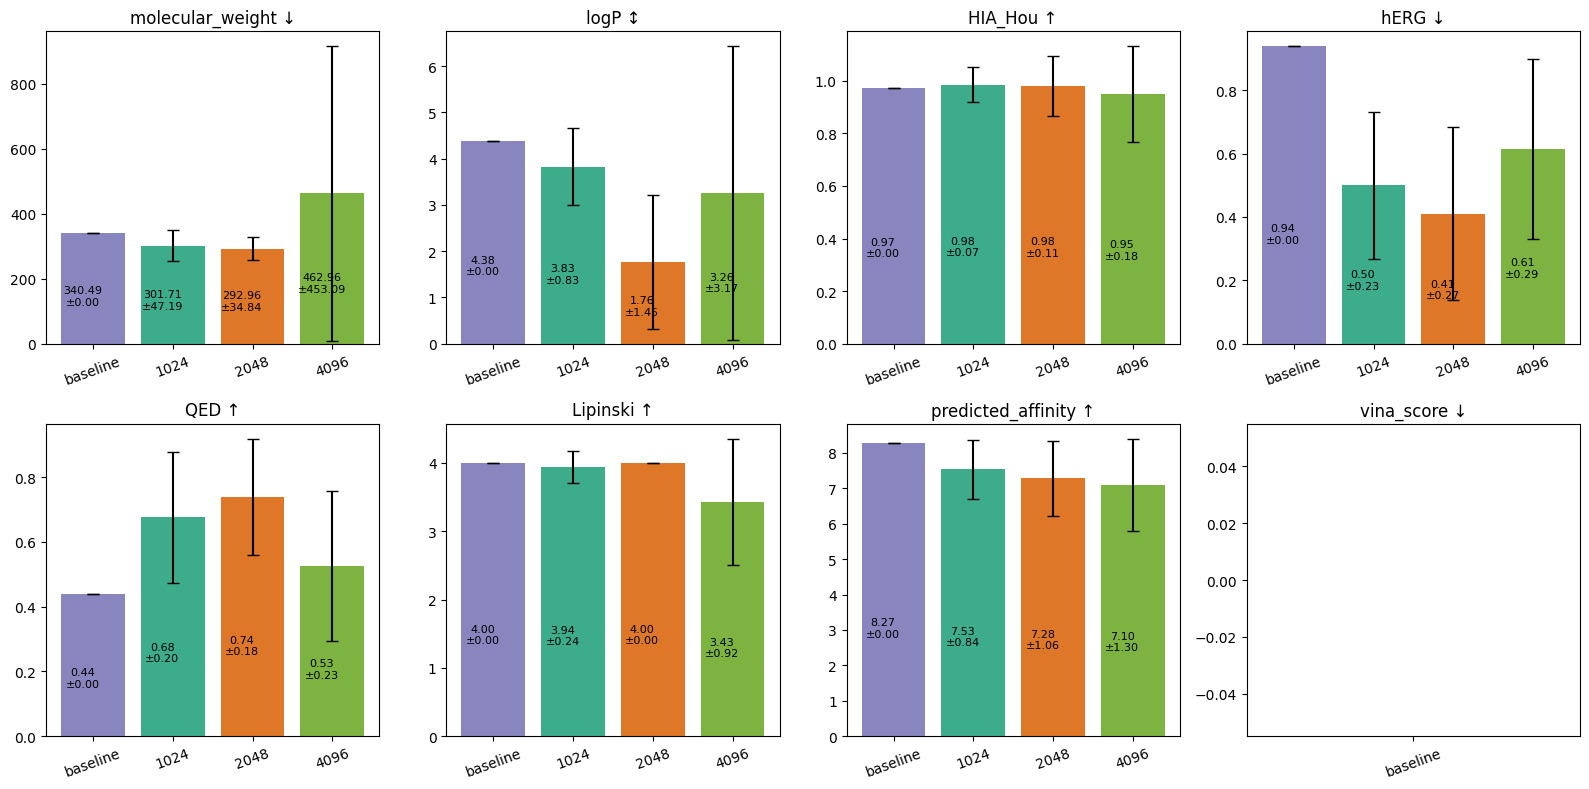

In [18]:
# Load reports for all runs
reports = {r["label"]: pd.read_csv(r["report_path"]) for r in runs}

metrics = [
    "molecular_weight",
    "logP",
    "HIA_Hou",
    "hERG",
    "QED",
    "Lipinski",
    "predicted_affinity",
    "vina_score",
]

colors = {"baseline": "#7570b3", "1024": "#1b9e77", "2048": "#d95f02", "4096": "#66a61e"}
labels = ["baseline", "1024", "2048", "4096"]


def idx_col(df):
    return df["dataset_index"] if "dataset_index" in df.columns else pd.Series(index=df.index, dtype=float)


def baseline_row(df, idx):
    br = df.loc[idx == -1]
    if not br.empty:
        return br.head(1)
    return df.head(1) if not df.empty else pd.DataFrame()


def masked_stats(df, col, mask):
    if col not in df.columns or df.empty:
        return np.nan, np.nan
    vals = df.loc[mask, col].dropna()
    if vals.empty:
        return np.nan, np.nan
    return vals.mean(), vals.std()

display_names = {
    "molecular_weight": "molecular_weight ↓",
    "logP": "logP ↕",
    "HIA_Hou": "HIA_Hou ↑",
    "hERG": "hERG ↓",               # lower is safer
    "QED": "QED ↑",
    "Lipinski": "Lipinski ↑",
    "predicted_affinity": "predicted_affinity ↑",
    "vina_score": "vina_score ↓",   # more negative is better
}


# Pick a baseline row from any run
baseline = pd.DataFrame()
idx_map = {}
for label, df in reports.items():
    idx_map[label] = idx_col(df)
    if label=="2048":
        if baseline.empty:
            candidate = baseline_row(df, idx_map[label])
            if not candidate.empty:
                baseline = candidate

rows = []
for m in metrics:
    base_mean = baseline.iloc[0].get(m, np.nan) if not baseline.empty else np.nan
    base_std = 0.0 if not baseline.empty and m in baseline.columns else np.nan
    rows.append({"metric": m, "group": "baseline", "mean": base_mean, "std": base_std})
    for label in ["1024", "2048", "4096"]:
        df = reports.get(label)
        idx = idx_map.get(label)
        if df is None or idx is None:
            rows.append({"metric": m, "group": label, "mean": np.nan, "std": np.nan})
            continue
        mask = (idx != -1) if not idx.empty else slice(None)
        mean, std = masked_stats(df, m, mask)
        rows.append({"metric": m, "group": label, "mean": mean, "std": std})

dfm = pd.DataFrame(rows)

ncols = 4
nrows = int(np.ceil(len(metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), sharey=False)
axes = np.array(axes).reshape(-1)

for ax, metric in zip(axes, metrics):
    sub = dfm[dfm["metric"] == metric].set_index("group")
    # (compute means/errs/bars as before)
    means = [sub.at[l, "mean"] if l in sub.index else np.nan for l in labels]
    errs = [sub.at[l, "std"] if l in sub.index else 0.0 for l in labels]
    bars = ax.bar(labels, means, yerr=errs, capsize=4, color=[colors[l] for l in labels], alpha=0.85)
    for b, mean, err in zip(bars, means, errs):
        if np.isnan(mean):
            continue
        ax.text(
            b.get_x() + b.get_width() / 3,
            b.get_height()/3,
            f"{mean:.2f}\n±{err:.2f}",
            ha="center", va="bottom", fontsize=8,
        )

    ax.set_title(display_names.get(metric, metric))

    ax.tick_params(axis='x', rotation=20)

for ax in axes[len(metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [19]:


# ### sars cov--- RDKit path fingerprint + Tversky 
# a = {
#     "label": "1024",
#     "opt": "ab8322096ede",
#     "report": "c302de47eac5",
# }

# #### sars-cov ... tanimoto sim full morgan finger print 1024 , 3 
# # a = {
# #     "label": "1024",
# #     "opt": "ab8322096ede",
# #     "report": "c3ee018a637a",
# # }

# #### sars-cov ...  my piplien 
# b = {
#     "label": "2048",
#     "opt": "ab8322096ede",
#     "report": "b7ad180a2493",
# }

# #### sars-cov ...  random
# c = {
#     "label": "4096",
#     "opt": "5e2e1ff84378",
#     "report": "df12841610db",
# }